In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'tmmn'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
noise = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# # Set exmaple lat and lon values
# lat_min, lat_max = 40.12, 40.13
# lon_min, lon_max = -110.09, -110.04
# time_dim = noise['time'].values.astype('float64')

# noise_masked = loc_mask(noise, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)


# def order_call(ds, order, var):
#     """
#     Unpacks necessary coefficients from curvefit dataset.
#     """
#     # Access offset coeff (in every dataset)
#     a0 = ds[f'{var}_curvefit_coefficients'].sel(param = 'a0').values.item()
    
#     # Create list to store coeffs in
#     coeff = [a0]

#     # Loop through however many coeff are in that order of harmonic function
#     for i in range(1, order+1):
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'a{i}').values.item())
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'b{i}').values.item())

#     return coeff

# first_coeff = order_call(first_masked, 1, var)
# second_coeff = order_call(second_masked, 2, var)
# third_coeff = order_call(third_masked, 3, var)

# # Pass them into your harmonic function to generate the smooth curve
# # * tells it to unpack the list
# smooth_first = harmonic_n(time_dim, *first_coeff) 
# smooth_second = harmonic_n(time_dim, *second_coeff)
# smooth_third = harmonic_n(time_dim, *third_coeff)

# # Squeeze out any extra dimensions (like lat, lon, or singleton axes) so it becomes a 1D array of length 60
# smooth_first_1d = np.squeeze(smooth_first)
# smooth_second_1d = np.squeeze(smooth_second)
# smooth_third_1d = np.squeeze(smooth_third)

# Also ensure your noise variable is 1D for that specific masked point
noise_y = noise_masked[var].isel(lat=0, lon=0).squeeze()


# ===============================
# - Plotting Harmonic Curves - 
# ===============================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    noise_masked['time'], 
    noise_y, 
    'ko', 
    alpha=0.4, 
    markersize=4, 
    label='Noisy Data (Climatology)'
)

# ax.plot(
#     noise_masked['time'], 
#     smooth_first_1d, 
#     'r-', 
#     linewidth=2, 
#     label='1st Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_second_1d, 
#     'g-', 
#     linewidth=2, 
#     label='2nd Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_third_1d, 
#     'b-', 
#     linewidth=2, 
#     label='3rd Order Harmonic'
# )

ax.set_title(f"{var} Climatology and Harmonic Fits", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel(var, fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

NameError: name 'noise_masked' is not defined

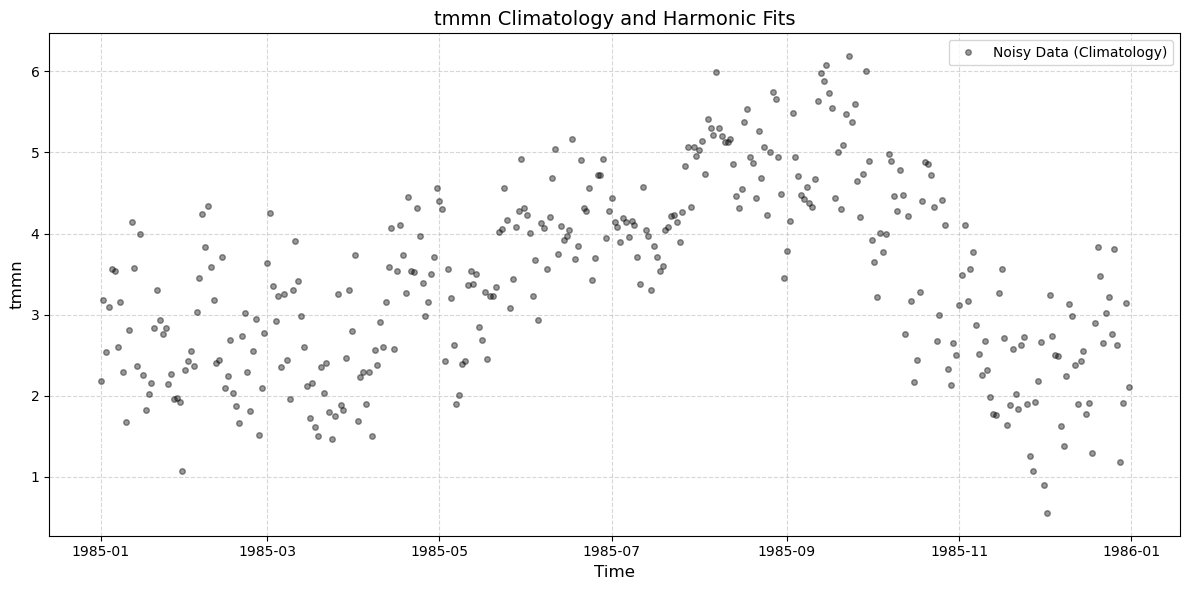

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'tmmn'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
noise = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(noise, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)


# def order_call(ds, order, var):
#     """
#     Unpacks necessary coefficients from curvefit dataset.
#     """
#     # Access offset coeff (in every dataset)
#     a0 = ds[f'{var}_curvefit_coefficients'].sel(param = 'a0').values.item()
    
#     # Create list to store coeffs in
#     coeff = [a0]

#     # Loop through however many coeff are in that order of harmonic function
#     for i in range(1, order+1):
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'a{i}').values.item())
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'b{i}').values.item())

#     return coeff

# first_coeff = order_call(first_masked, 1, var)
# second_coeff = order_call(second_masked, 2, var)
# third_coeff = order_call(third_masked, 3, var)

# # Pass them into your harmonic function to generate the smooth curve
# # * tells it to unpack the list
# smooth_first = harmonic_n(time_dim, *first_coeff) 
# smooth_second = harmonic_n(time_dim, *second_coeff)
# smooth_third = harmonic_n(time_dim, *third_coeff)

# # Squeeze out any extra dimensions (like lat, lon, or singleton axes) so it becomes a 1D array of length 60
# smooth_first_1d = np.squeeze(smooth_first)
# smooth_second_1d = np.squeeze(smooth_second)
# smooth_third_1d = np.squeeze(smooth_third)

# Also ensure your noise variable is 1D for that specific masked point
noise_y = noise_masked[var].isel(lat=0, lon=0).squeeze()


# ===============================
# - Plotting Harmonic Curves - 
# ===============================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    noise_masked['time'], 
    noise_y, 
    'ko', 
    alpha=0.4, 
    markersize=4, 
    label='Noisy Data (Climatology)'
)

# ax.plot(
#     noise_masked['time'], 
#     smooth_first_1d, 
#     'r-', 
#     linewidth=2, 
#     label='1st Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_second_1d, 
#     'g-', 
#     linewidth=2, 
#     label='2nd Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_third_1d, 
#     'b-', 
#     linewidth=2, 
#     label='3rd Order Harmonic'
# )

ax.set_title(f"{var} Climatology and Harmonic Fits", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel(var, fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()